# Projet Seaborn: Capteurs IoT (température, humidité, pression, énergie)

**Contexte :** après NumPy, Pandas et Matplotlib, on utilise **Seaborn** pour une analyse exploratoire plus riche : distributions avancées, comparaisons entre groupes, corrélations et relations multivariées.

Structure du projet :
```
Seaborn_Iot_Analysis/
├── data/mesures_capteurs.csv
├── notebooks/Seaborn_Iot_Analysis.ipynb
└── exports/temperature.png, temperature.pdf, ...
```


### Installation, imports et chargement des données

Seaborn s'appuie sur Matplotlib et fonctionne très bien avec des DataFrames Pandas : on lui passe directement le DataFrame et les noms de colonnes, sans extraire les valeurs à la main.

In [4]:
!pip install seaborn matplotlib pandas numpy

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [10]:
sns.set_theme(style="whitegrid")

# Import du dataset
df=pd.read_csv("../data/mesures_capteurs.csv")
df["date_heure"]=pd.to_datetime(df["date_heure"])

#6) Vérification du contenu
print(df.shape)
df.head()

(605, 9)


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    object        
 1   date_heure    605 non-null    datetime64[ns]
 2   id_capteur    605 non-null    object        
 3   batiment      605 non-null    object        
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 42.7+ KB


## Partie 1 : Distribution d'une variable avec `histplot()`

`histplot()` affiche un histogramme (comme Matplotlib) mais avec une syntaxe orientée DataFrame et des options avancées (regroupement par catégorie, courbe de densité superposée...).

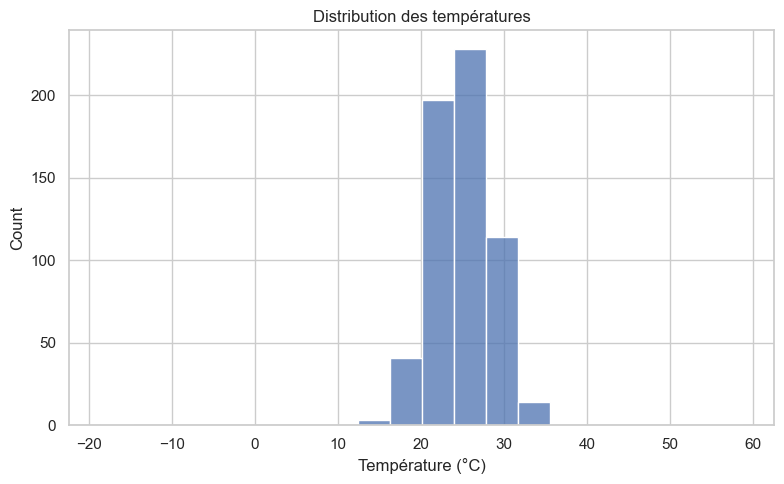

In [12]:
# 1) Distribution des températures
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", bins=20)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()

**2) Concentration :** les températures se concentrent autour de la valeur moyenne du jeu de données (proche de 25°C).
**3) Symétrie :** la distribution paraît globalement symétrique, en forme de cloche.
**4) Valeurs extrêmes :** quelques barres isolées, très écartées du groupe principal, suggèrent la présence de valeurs extrêmes.

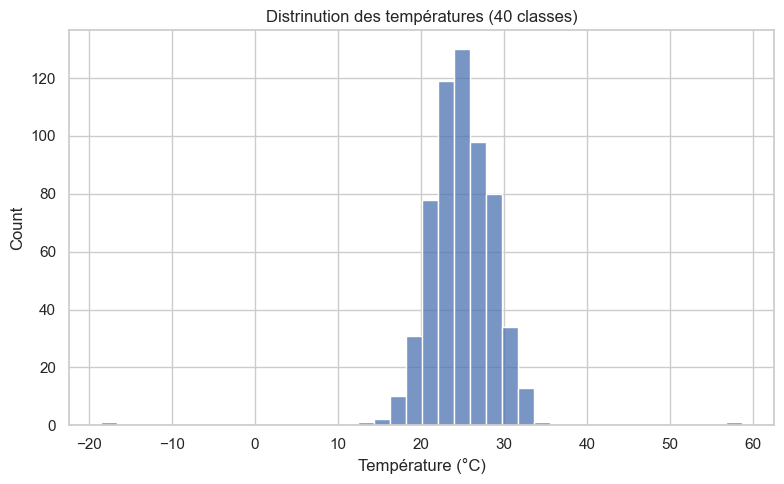

In [13]:
# 5) Modification du nombre de classes
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", bins=40)
plt.title("Distrinution des températures (40 classes)")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()

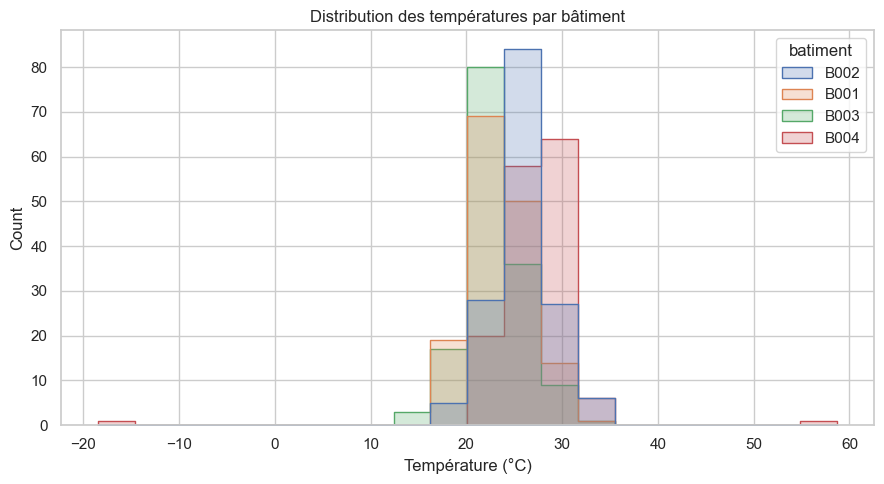

In [14]:
# 6) Distribution des températures par bâtiment
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", bins=20, element="step")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()


## Partie 2 : Distribution d'une variable avec `kdeplot()`

`kdeplot()` (*Kernel Density Estimate*) trace une **courbe de densité lissée** de la distribution, une alternative continue à l'histogramme.

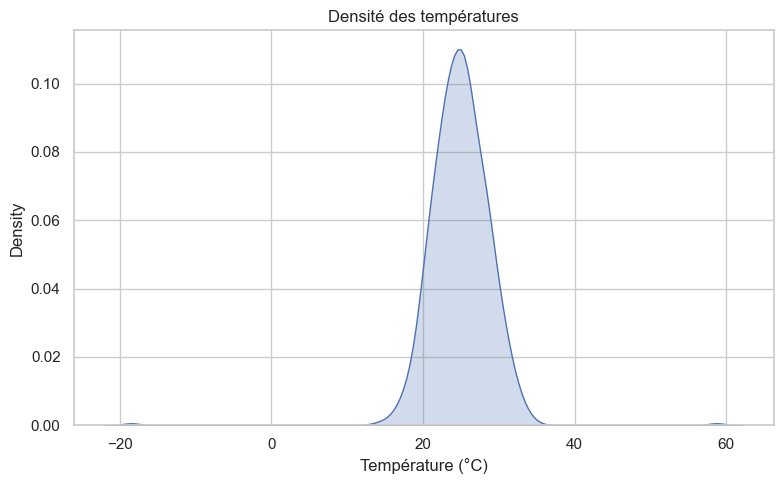

In [15]:
# 1) Distribution des températures (courbe de densité)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="temperature", fill=True)
plt.title("Densité des températures")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()


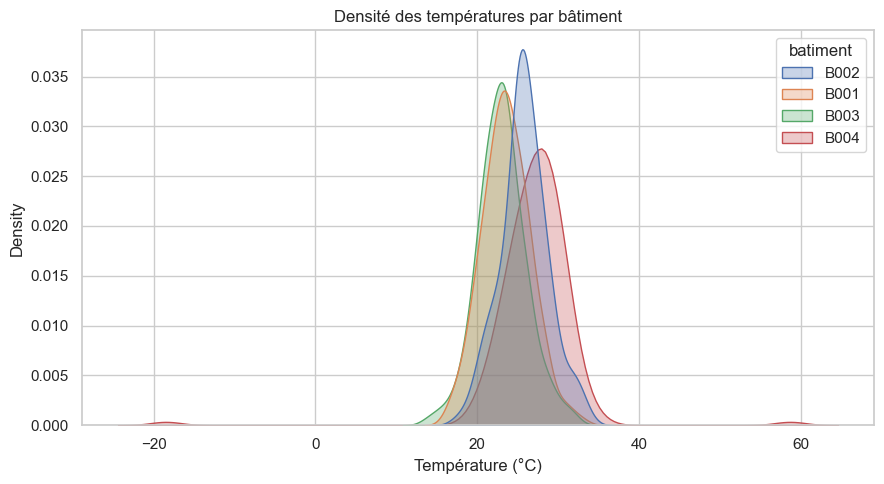

In [16]:
# 2) Distribution des températures par bâtiment
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.3)
plt.title("Densité des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()


## Partie 3 : Distribution d'une variable avec `boxplot()`

Le box plot Seaborn résume une distribution (médiane, quartiles, valeurs extrêmes) et permet très facilement de **comparer plusieurs groupes** (ici, les bâtiments) sur un même graphique.

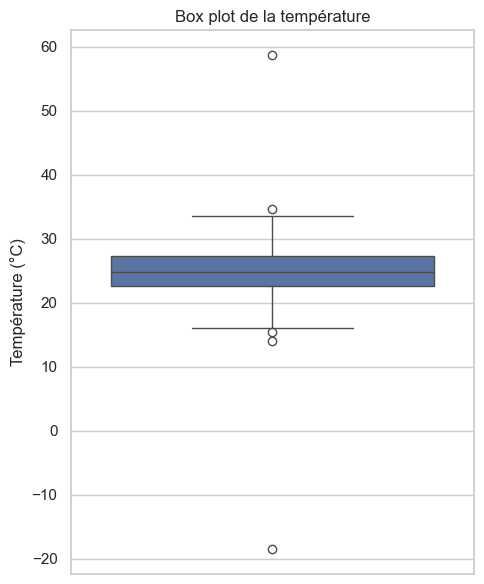

In [17]:
# 1) Distribution de la température (ensemble du dataset)
plt.figure(figsize=(5, 6))
sns.boxplot(data=df, y="temperature")
plt.title("Box plot de la température")
plt.ylabel("Température (°C)")
plt.tight_layout()
plt.show()


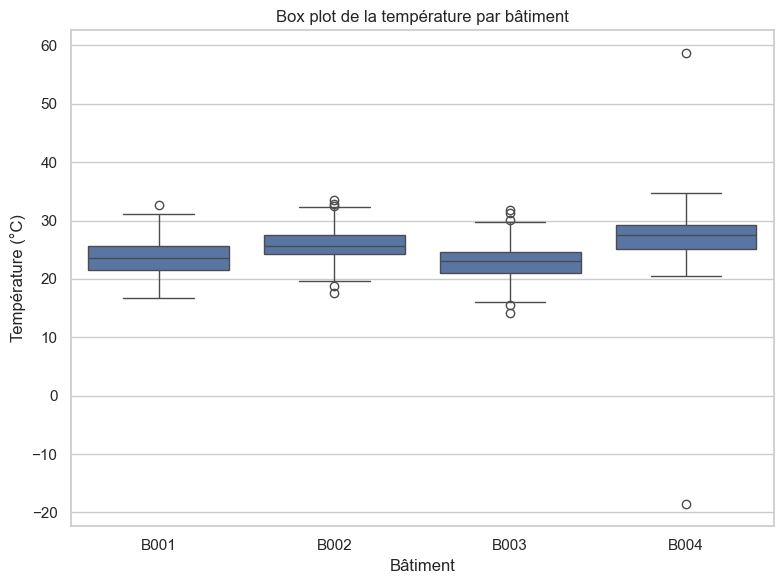

In [18]:
# 2) Distribution des températures par bâtiment
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="batiment", y="temperature", order=sorted(df["batiment"].unique()))
plt.title("Box plot de la température par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.tight_layout()
plt.show()


In [19]:
# 3) Médiane, dispersion (IQR) et valeurs extrêmes, par bâtiment
resume_batiment = df.groupby("batiment")["temperature"].describe()[["50%", "25%", "75%", "min", "max"]]
resume_batiment["IQR"] = resume_batiment["75%"] - resume_batiment["25%"]
resume_batiment


,50%,25%,75%,min,max,IQR
batiment,,,,,,
B001,23.540,21.6100,25.6700,16.77,32.72,4.0600
B002,25.670,24.2675,27.5300,17.67,33.60,3.2625
B003,23.045,21.0825,24.5950,14.11,31.74,3.5125
B004,27.535,25.1750,29.2825,-18.50,58.70,4.1075


**3) Lecture du tableau ci-dessus, pour chaque bâtiment :**
- **a) Médiane :** colonne `50%`.
- **b) Dispersion :** colonne `IQR` (écart interquartile) — plus elle est grande, plus les valeurs centrales sont dispersées.
- **c) Valeurs extrêmes :** colonnes `min`/`max`, à comparer aux moustaches du box plot pour repérer les outliers.

**4) Bâtiments aux valeurs les plus extrêmes :** ce sont ceux dont les colonnes `min`/`max` (ou les points isolés sur le graphique) s'écartent le plus du reste — à identifier directement sur le tableau et le graphique ci-dessus.

## Partie 4 : Distribution d'une variable avec `violinplot()`

Le violin plot combine un box plot et une courbe de densité : il montre à la fois les statistiques-clés **et** la forme complète de la distribution (largeur = concentration des valeurs).

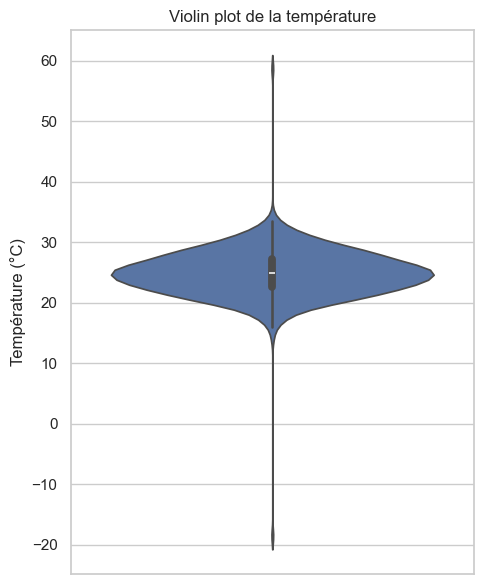

In [20]:
# 1) Distribution de la température (ensemble du dataset)
plt.figure(figsize=(5, 6))
sns.violinplot(data=df, y="temperature")
plt.title("Violin plot de la température")
plt.ylabel("Température (°C)")
plt.tight_layout()
plt.show()


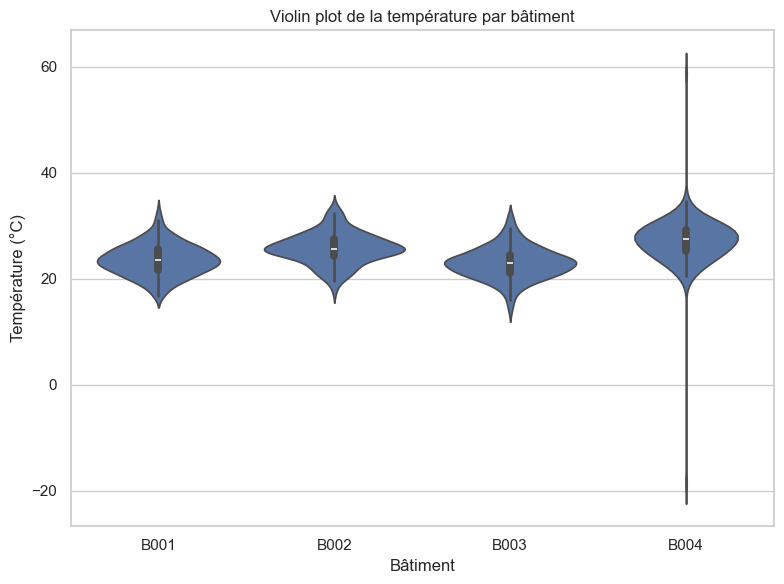

In [21]:
# 2) Distribution des températures par bâtiment
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x="batiment", y="temperature", order=sorted(df["batiment"].unique()))
plt.title("Violin plot de la température par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.tight_layout()
plt.show()


**3) Apport du violin plot par rapport au box plot :** le box plot ne montre que des statistiques résumées (médiane, quartiles), alors que le violin plot affiche en plus la **forme complète de la distribution** — on voit si les valeurs sont concentrées en un seul pic, réparties sur deux pics (bimodal), etc., ce qui est invisible sur un simple box plot.

## Partie 5 : Comptage des catégories avec `countplot()`

`countplot()` affiche le **nombre d'occurrences** de chaque catégorie — l'équivalent visuel d'un `value_counts()`.

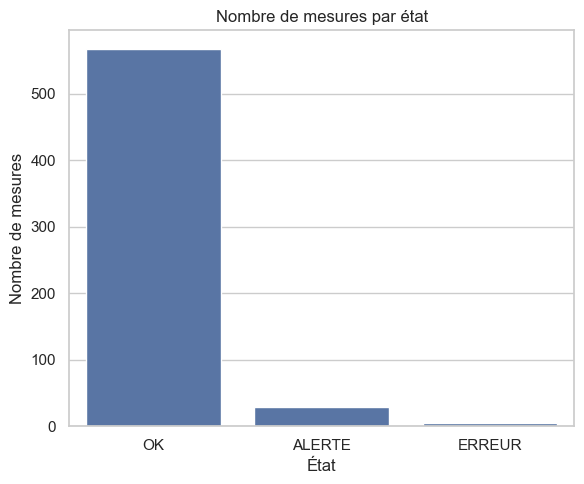

In [22]:
# 1) Nombre de mesures par état
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="etat", order=df["etat"].value_counts().index)
plt.title("Nombre de mesures par état")
plt.xlabel("État")
plt.ylabel("Nombre de mesures")
plt.tight_layout()
plt.show()


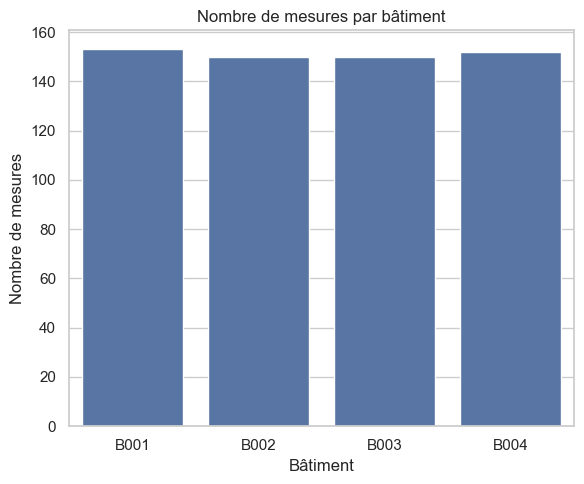

In [23]:
# 2) Nombre de mesures par bâtiment
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="batiment", order=sorted(df["batiment"].unique()))
plt.title("Nombre de mesures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.tight_layout()
plt.show()


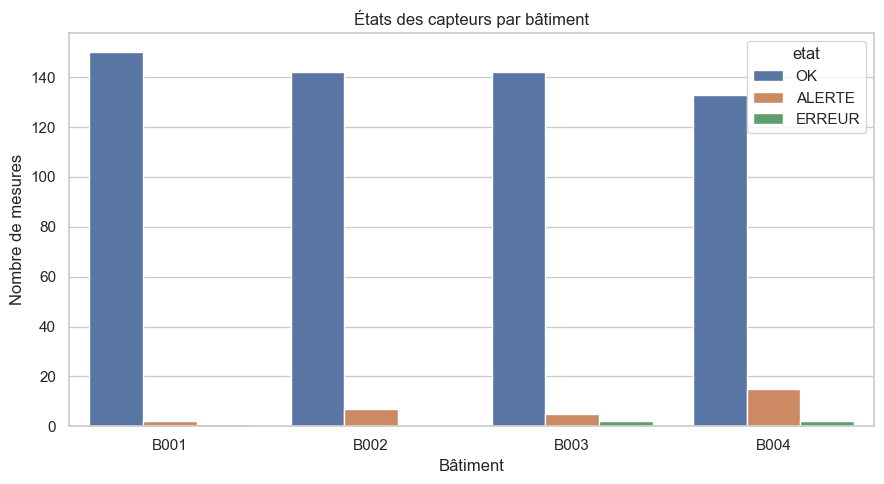

In [24]:
# 3) États des capteurs par bâtiment
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="batiment", hue="etat", order=sorted(df["batiment"].unique()))
plt.title("États des capteurs par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.tight_layout()
plt.show()


In [25]:
# Tableau croisé pour répondre précisément aux questions a), b), c)
tableau_croise = pd.crosstab(df["batiment"], df["etat"])
print(tableau_croise)
print()
print("a) Bâtiment avec le plus de mesures OK :", tableau_croise["OK"].idxmax())
print("b) Bâtiment avec le plus de mesures ALERTE :", tableau_croise["ALERTE"].idxmax())
print("c) Bâtiment avec le plus de mesures ERREUR :", tableau_croise["ERREUR"].idxmax())


etat      ALERTE  ERREUR   OK
batiment                     
B001           2       1  150
B002           7       0  142
B003           5       2  142
B004          15       2  133

a) Bâtiment avec le plus de mesures OK : B001
b) Bâtiment avec le plus de mesures ALERTE : B004
c) Bâtiment avec le plus de mesures ERREUR : B003


## Partie 6 : Relation entre deux variables avec `scatterplot()`

Le nuage de points Seaborn permet, en plus de la relation entre deux variables numériques, d'**ajouter facilement une dimension catégorielle** via une couleur (`hue`).

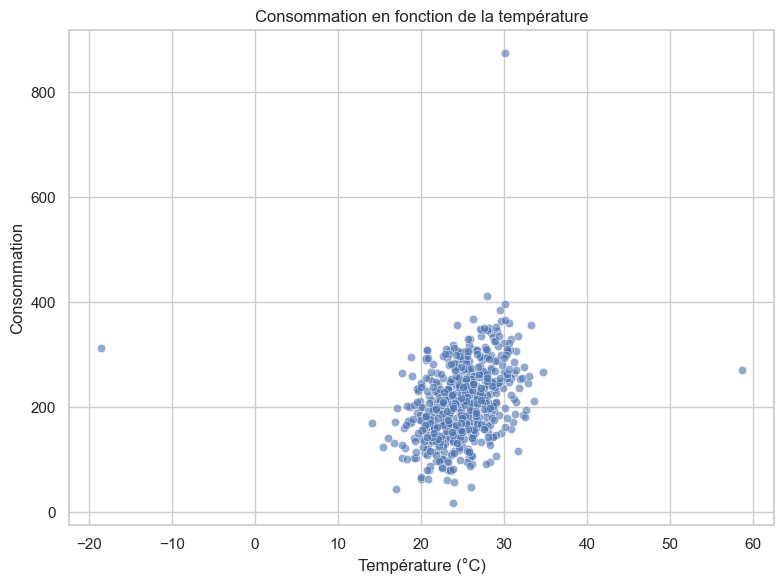

In [26]:
# 1) Relation entre température et consommation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", alpha=0.6)
plt.title("Consommation en fonction de la température")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.tight_layout()
plt.show()


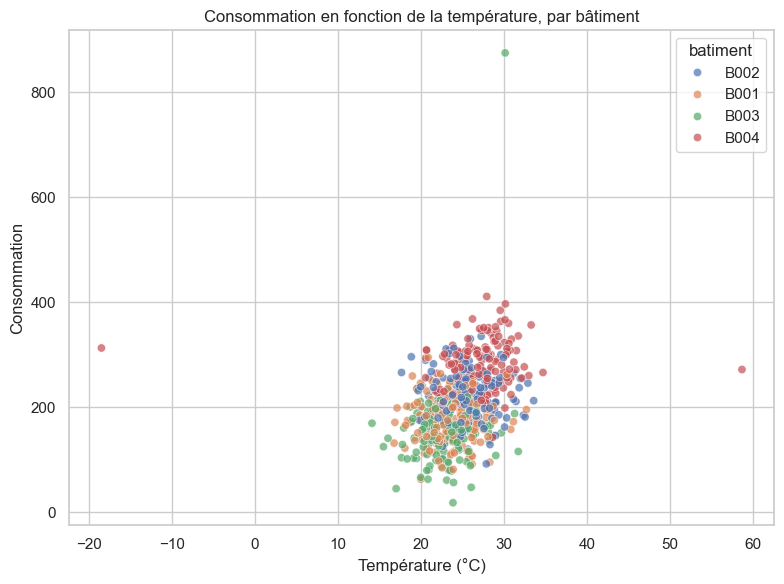

In [27]:
# 2) Relation entre température et consommation, par bâtiment
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", alpha=0.7)
plt.title("Consommation en fonction de la température, par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.tight_layout()
plt.show()


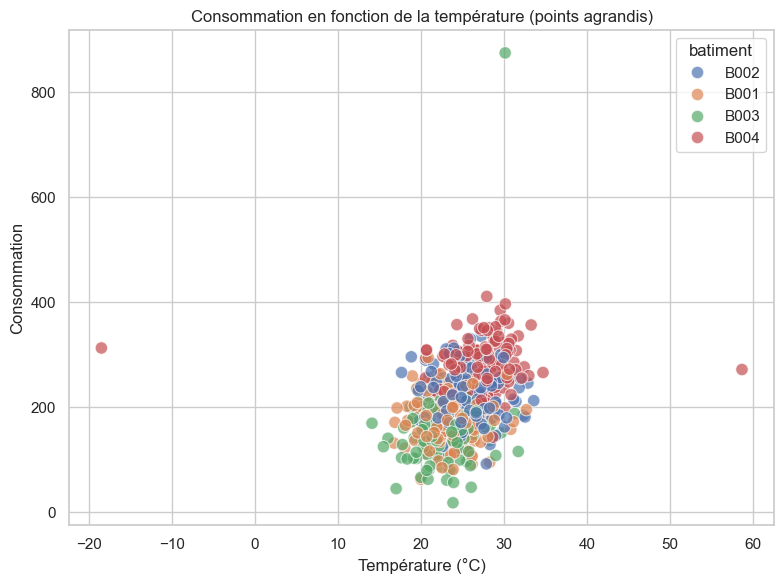

In [28]:
# 3) Modification de la taille des points
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", alpha=0.7, s=80)
plt.title("Consommation en fonction de la température (points agrandis)")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.tight_layout()
plt.show()
